In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import calendar
from statsmodels.nonparametric.smoothers_lowess import lowess


In [ ]:
df=pd.read_csv('temperature_nsw.csv')


In [ ]:
#Check for null values
print(df.isna().sum().sort_values(ascending=False))

LOCATION       0
DATETIME       0
TEMPERATURE    0
dtype: int64


Okay so we have don't have any null values we will check for datatypes

In [ ]:
#Check for datatypes
print(df.dtypes)

LOCATION        object
DATETIME        object
TEMPERATURE    float64
dtype: object


Okay so there is problem DataTime column should be in datatime format, but it is in object.

In [ ]:
s=df['DATETIME'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
df['DATETIME'] = pd.to_datetime(
    s,
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)
print(df.dtypes)

LOCATION               object
DATETIME       datetime64[ns]
TEMPERATURE           float64
dtype: object


In [ ]:
print(f"Number of unique values:  {df['LOCATION'].nunique()}") #Number of unique values
print(f"Unique Values: {sorted(df['LOCATION'].unique().tolist())}")  #Unique values

Number of unique values:  1
Unique Values: ['Bankstown']


In [ ]:
#Now we will check for mean mode and other statistical calculation of Temperature
df['TEMPERATURE'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,TEMPERATURE
count,220326.000000
mean,17.418827
std,5.849763
min,-1.300000
1%,4.500000
5%,7.400000
25%,13.400000
50%,17.700000
75%,21.300000
95%,26.700000


Now we will check for outliers

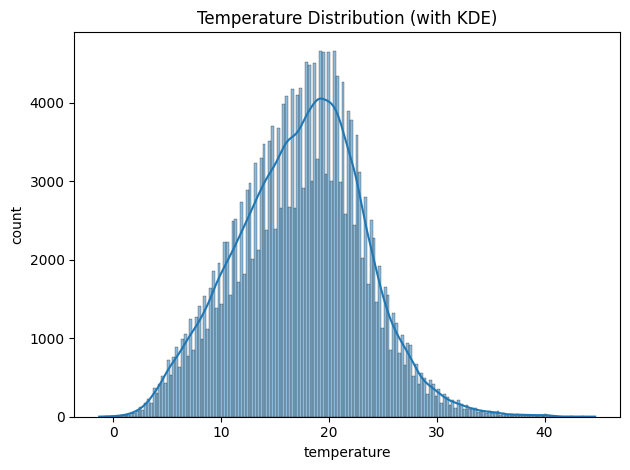

In [ ]:
#Histogram with KDE
plt.figure()
sns.histplot(df['TEMPERATURE'], kde=True, bins="auto")
plt.title("Temperature Distribution (with KDE)")
plt.xlabel("temperature")
plt.ylabel("count")
plt.tight_layout()

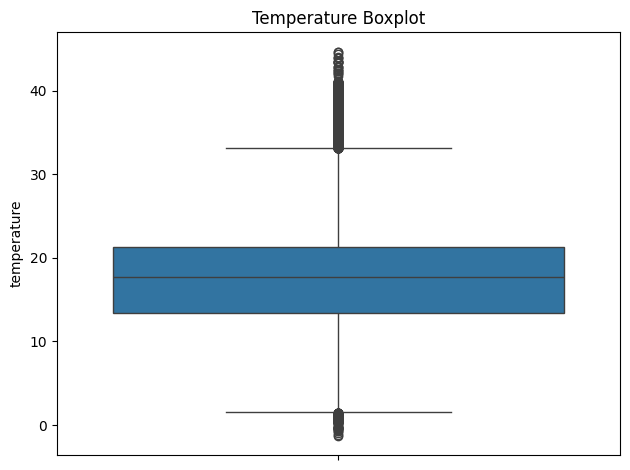

In [ ]:
#Now box plot
# 2) Boxplot (shows IQR-based outliers)
plt.figure()
sns.boxplot(y=df['TEMPERATURE'])
plt.title("Temperature Boxplot")
plt.ylabel("temperature")
plt.tight_layout()

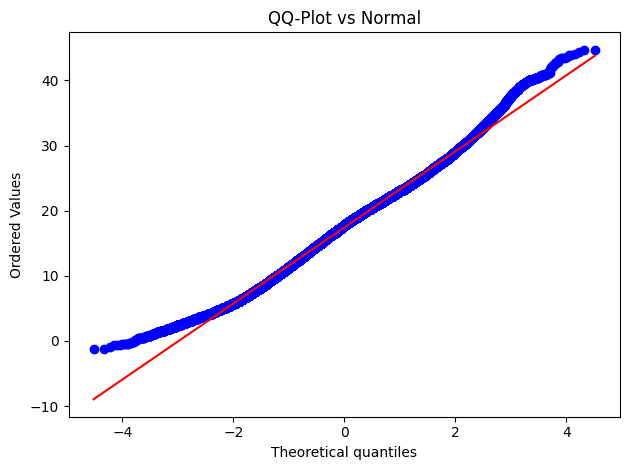

In [ ]:
#QQ plot
plt.figure()
stats.probplot(df['TEMPERATURE'], dist="norm", plot=plt)
plt.title("QQ-Plot vs Normal")
plt.tight_layout()

So the Values of Temperature are pretty normally distributed
Now we are going to draw some Graphs to Analyze the relationship between Temperature and time

In [ ]:
df = df.set_index("DATETIME")
# Convenience columns for grouping
df["month"] = df.index.month
df["month_name"] = df.index.month_name()
df["dow"] = df.index.dayofweek
df["dow_name"] = df.index.day_name()
df["hour"] = df.index.hour

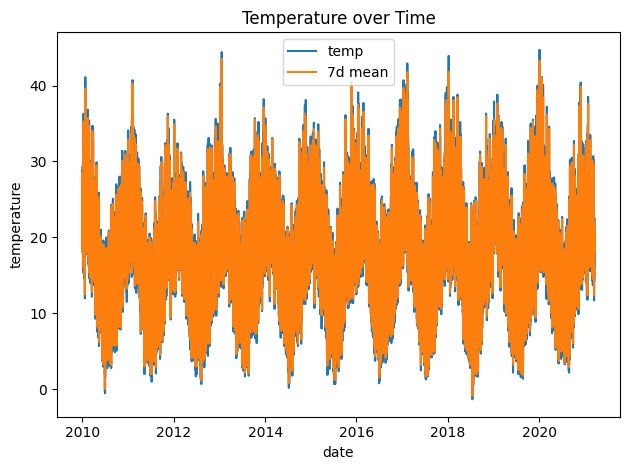

In [ ]:

plt.figure()
sns.lineplot(x=df.index, y=df["TEMPERATURE"], label="temp")
sns.lineplot(x=df.index, y=df["TEMPERATURE"].rolling(7, min_periods=1).mean(), label="7d mean")
plt.title("Temperature over Time")
plt.xlabel("date"); plt.ylabel("temperature"); plt.tight_layout()

Now we check for Months and weekly and daily


/tmp/ipython-input-1527363519.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base["month_name"] = base.index.month_name()


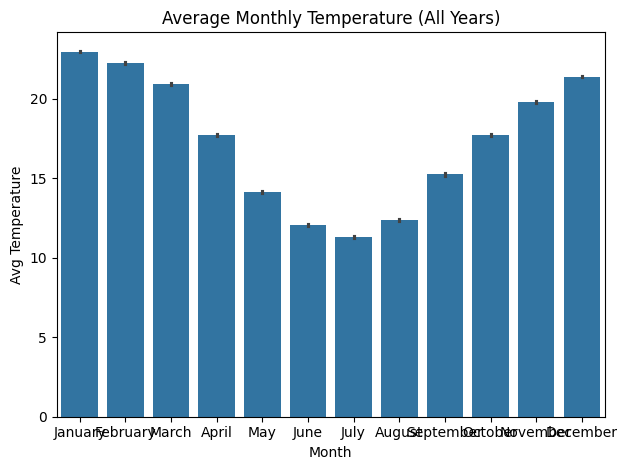

In [ ]:
base = df[["TEMPERATURE"]]

# Month labels in calendar order
month_order = list(calendar.month_name)[1:]  # ['January', ..., 'December']

# Add month names
base["month_name"] = base.index.month_name()

# --- Bar plot: average monthly temperature (pooled over all years) ---
plt.figure()
sns.barplot(data=base, x="month_name", y="TEMPERATURE",
            order=month_order, estimator=np.mean)
plt.title("Average Monthly Temperature (All Years)")
plt.xlabel("Month"); plt.ylabel("Avg Temperature")
plt.tight_layout()

In [ ]:
df2=pd.read_csv("totaldemand_nsw.csv")
df3=pd.read_csv("forecastdemand_nsw.csv")

In [ ]:
df3.head()

,PREDISPATCHSEQNO,REGIONID,PERIODID,FORECASTDEMAND,LASTCHANGED,DATETIME
0,2009123018,NSW1,71.0,7832.04,2009-12-30 12:31:49,2010-01-01 00:00:00
1,2009123019,NSW1,70.0,7832.04,2009-12-30 13:01:43,2010-01-01 00:00:00
2,2009123020,NSW1,69.0,7832.03,2009-12-30 13:31:36,2010-01-01 00:00:00
3,2009123021,NSW1,68.0,7832.03,2009-12-30 14:01:44,2010-01-01 00:00:00
4,2009123022,NSW1,67.0,7830.96,2009-12-30 14:31:35,2010-01-01 00:00:00


In [ ]:
#Check for null values
print(f"Null Values => {df2.isna().sum().sort_values(ascending=False)}")
#Check for datatypes
print(f"Data Types**  {df2.dtypes}")

Null Values => DATETIME       0
TOTALDEMAND    0
REGIONID       0
dtype: int64
Data Types**  DATETIME        object
TOTALDEMAND    float64
REGIONID        object
dtype: object


As we can see there is no null Values and Data Types are what we need. DateTime for DATETIME column and float and object for Totaldemand and RegioId columns respectively

Now we will draw bunch of graphs to check for outliers.

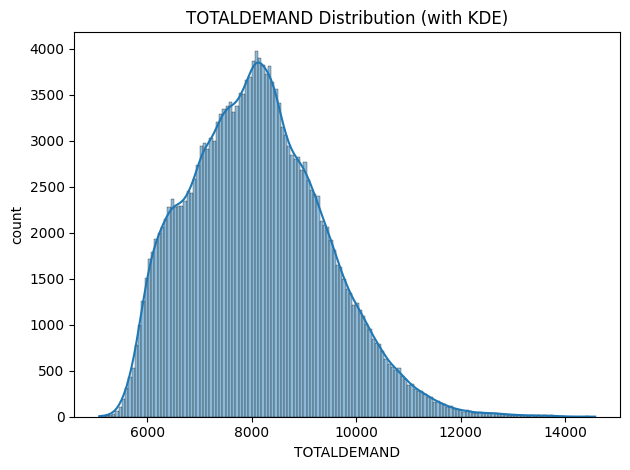

In [ ]:
#Histogram with KDE
plt.figure()
sns.histplot(df2['TOTALDEMAND'], kde=True, bins="auto")
plt.title("TOTALDEMAND Distribution (with KDE)")
plt.xlabel("TOTALDEMAND")
plt.ylabel("count")
plt.tight_layout()

Okay so it is Right Skewed and not normally distributed. It has a long tail on right


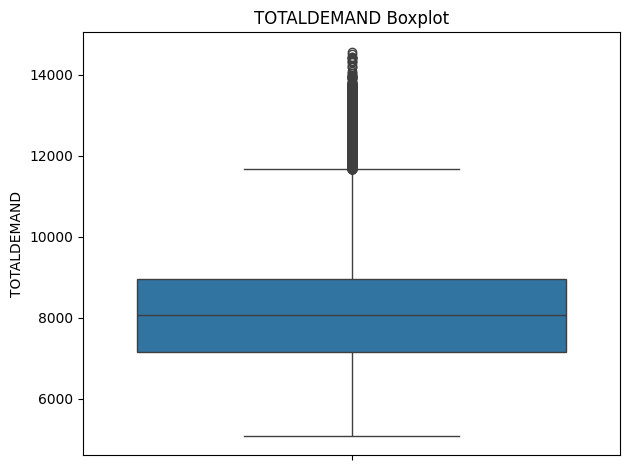

In [ ]:
#Now box plot
# 2) Boxplot (shows IQR-based outliers)
plt.figure()
sns.boxplot(y=df2['TOTALDEMAND'])
plt.title("TOTALDEMAND Boxplot")
plt.ylabel("TOTALDEMAND")
plt.tight_layout()

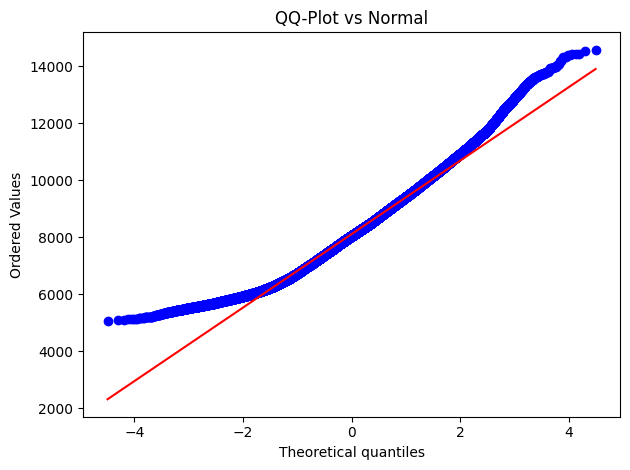

In [ ]:
#QQ plot
plt.figure()
stats.probplot(df2['TOTALDEMAND'], dist="norm", plot=plt)
plt.title("QQ-Plot vs Normal")
plt.tight_layout()

So the conclusion is Total demand is not normally distributed

# Forcasted vs Actual

Now we are going to compare the Forecasted demand and the Acutual demand. We will see how much both of these will deviate from each other



Integrating Totaldemand dataset and Temperature dataset

In [ ]:
#Setting Datetime as index
df2["DATETIME"]  = pd.to_datetime(df2["DATETIME"],  errors="coerce")
df2 = df2.set_index("DATETIME")

In [ ]:
df2.head()

,TOTALDEMAND,REGIONID
DATETIME,,
2010-01-01 00:00:00,8038.00,NSW1
2010-01-01 00:30:00,7809.31,NSW1
2010-01-01 01:00:00,7483.69,NSW1
2010-01-01 01:30:00,7117.23,NSW1
2010-01-01 02:00:00,6812.03,NSW1


In [ ]:

ac_df = df2.join(df[["TEMPERATURE",'LOCATION']], how="inner")

We will check for null values


In [ ]:
#Check for null values
print(ac_df.isna().sum().sort_values(ascending=False))

TOTALDEMAND    0
REGIONID       0
TEMPERATURE    0
LOCATION       0
dtype: int64


Okay so there are no null values, we are going to draw a line plot between demand and temperature. This will give us insight how the demand increase or decreace with Temperature

In [ ]:
ac_df = ac_df[~ac_df.index.duplicated(keep="first")]


/tmp/ipython-input-3277282309.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ac_df["DEMAND_mm2temp"] = ( (d - d.min()) / (d.max() - d.min()) ) * (t.max() - t.min()) + t.min()


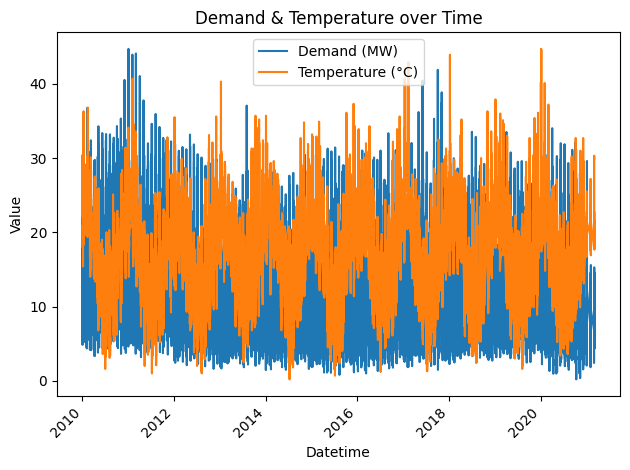

In [ ]:


t = ac_df["TEMPERATURE"]
d = ac_df["TOTALDEMAND"]

# scale demand to the temperature range [temp_min, temp_max]
ac_df["DEMAND_mm2temp"] = ( (d - d.min()) / (d.max() - d.min()) ) * (t.max() - t.min()) + t.min()


ax = sns.lineplot(data=ac_df, x=ac_df.index, y="DEMAND_mm2temp", label="Demand (MW)")
sns.lineplot(data=ac_df, x=ac_df.index, y="TEMPERATURE",  label="Temperature (°C)", ax=ax)

ax.set_title("Demand & Temperature over Time")
ax.set_xlabel("Datetime")
ax.set_ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

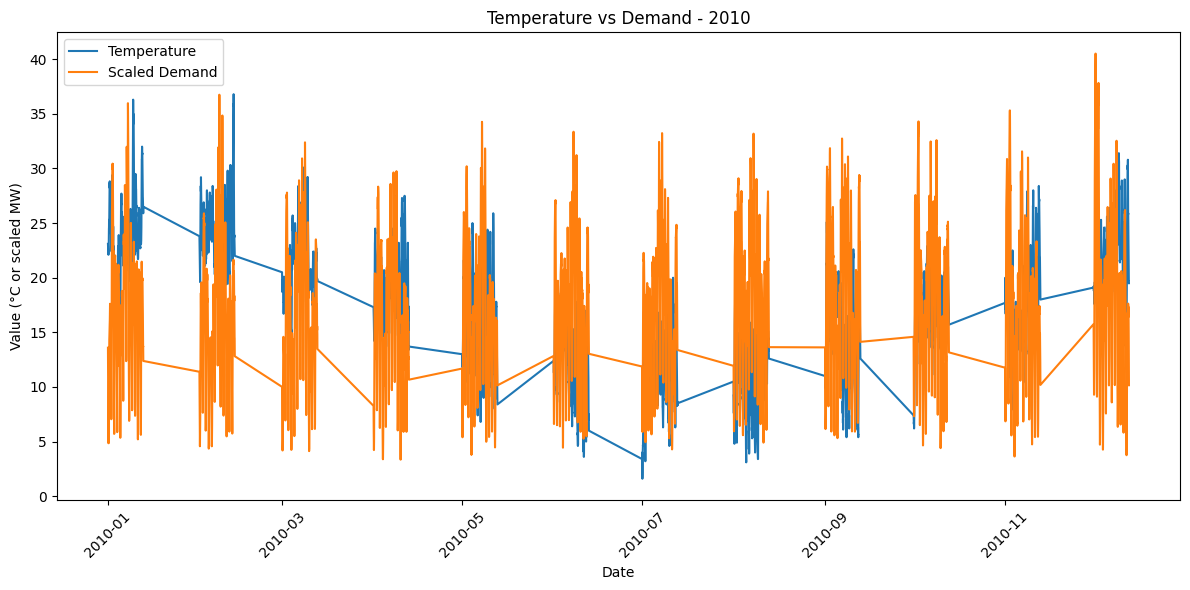

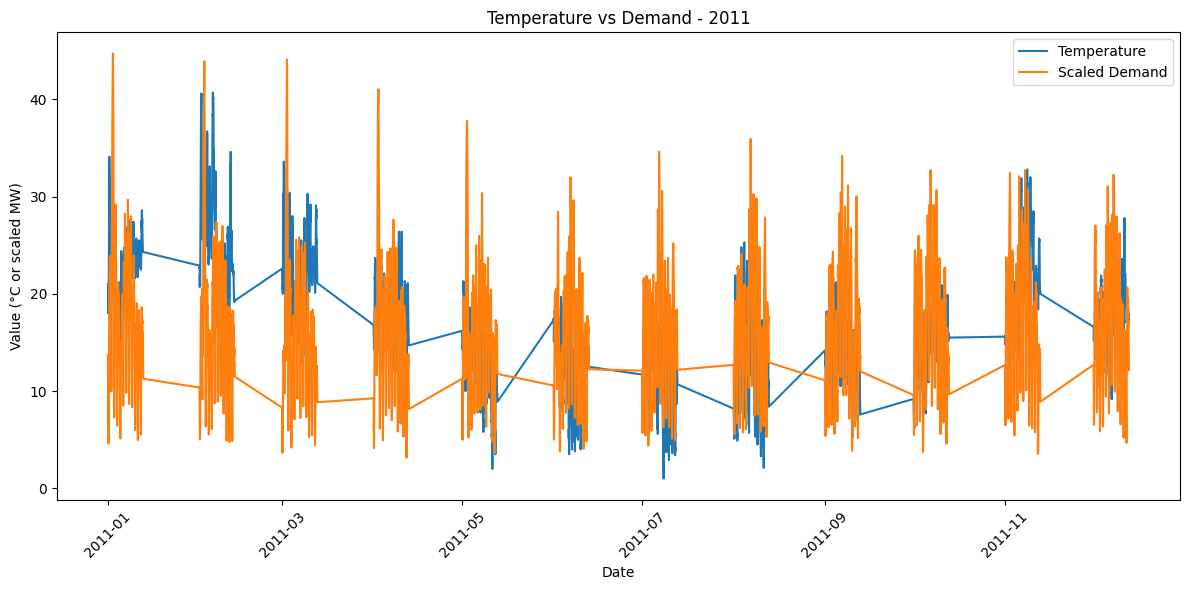

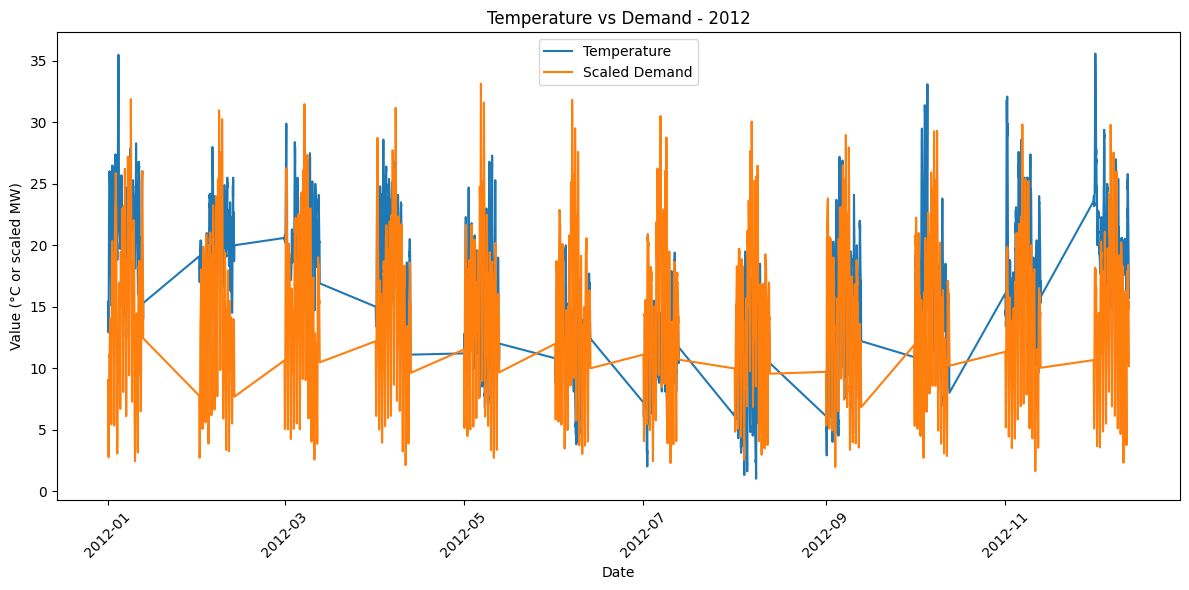

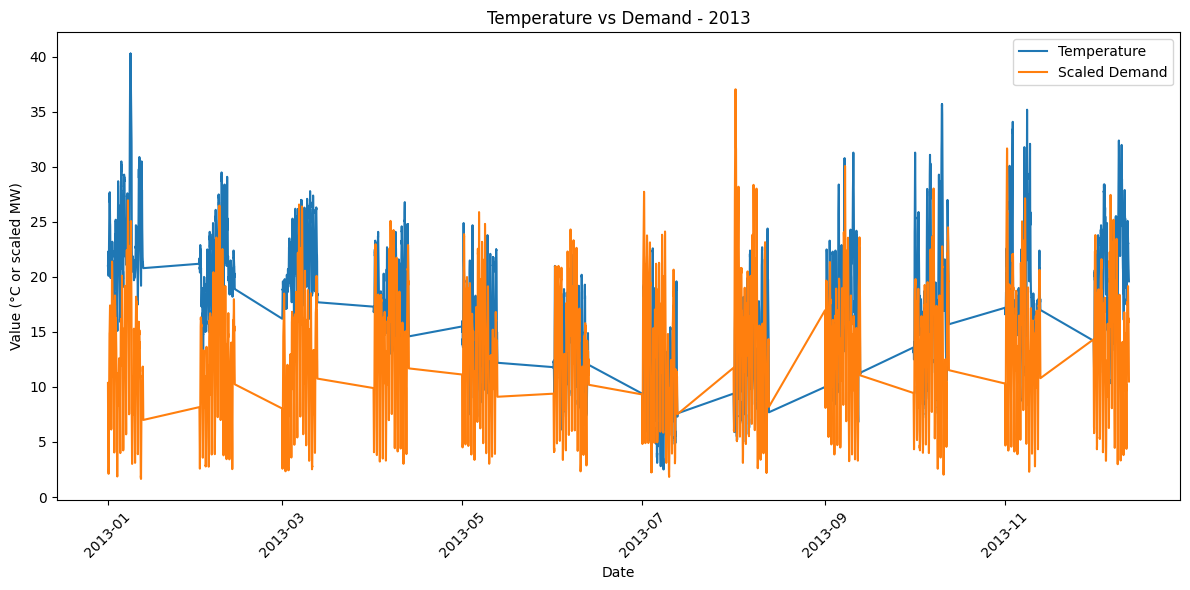

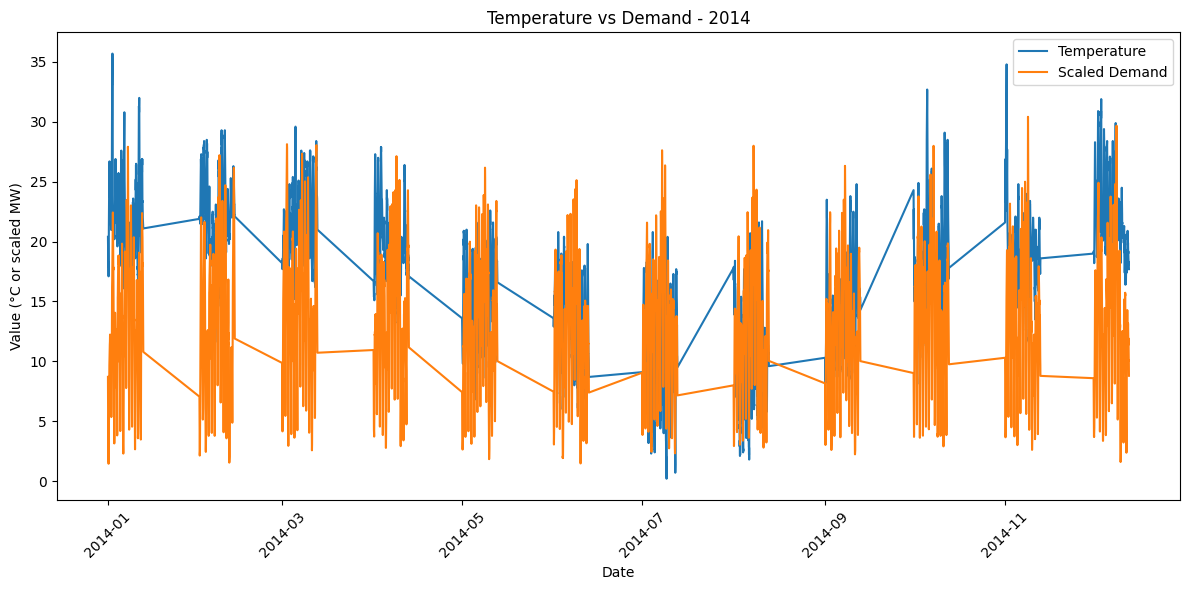

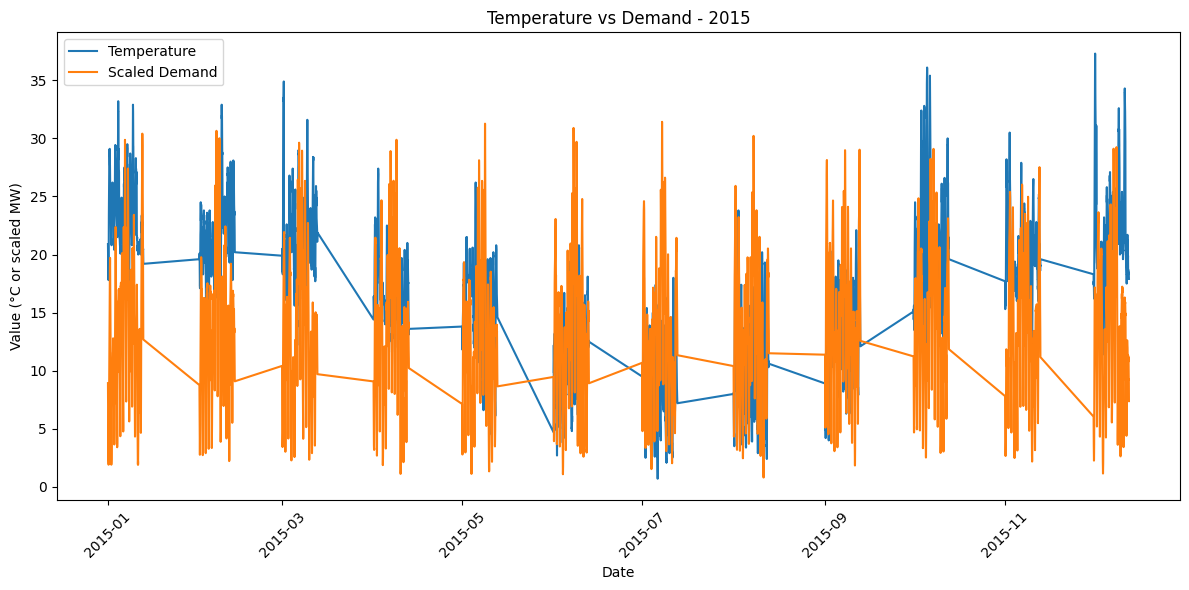

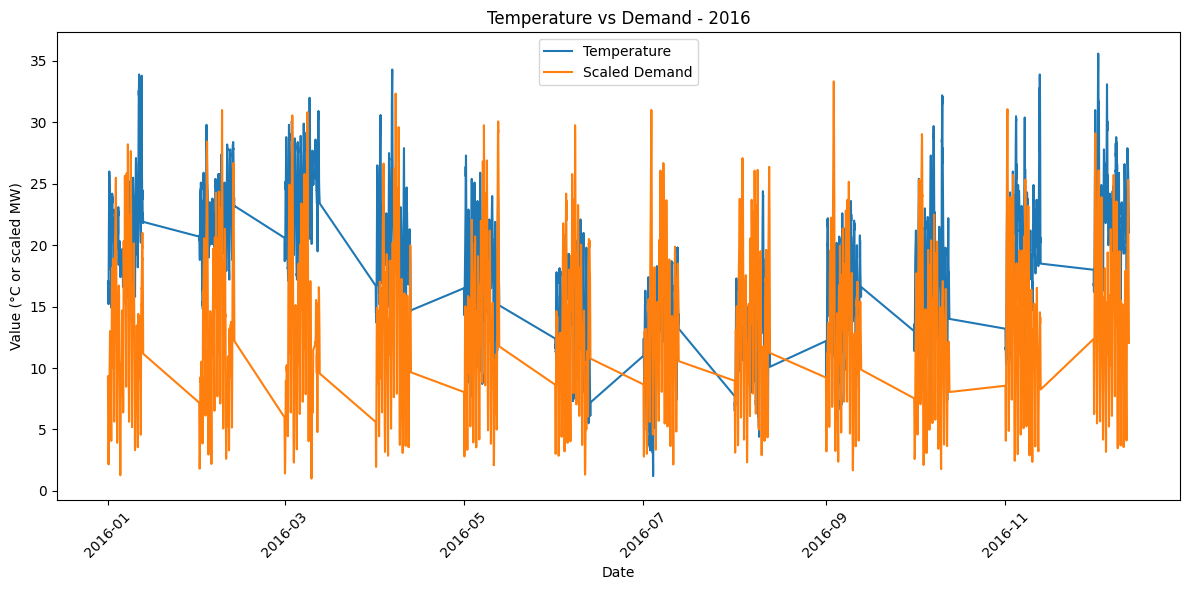

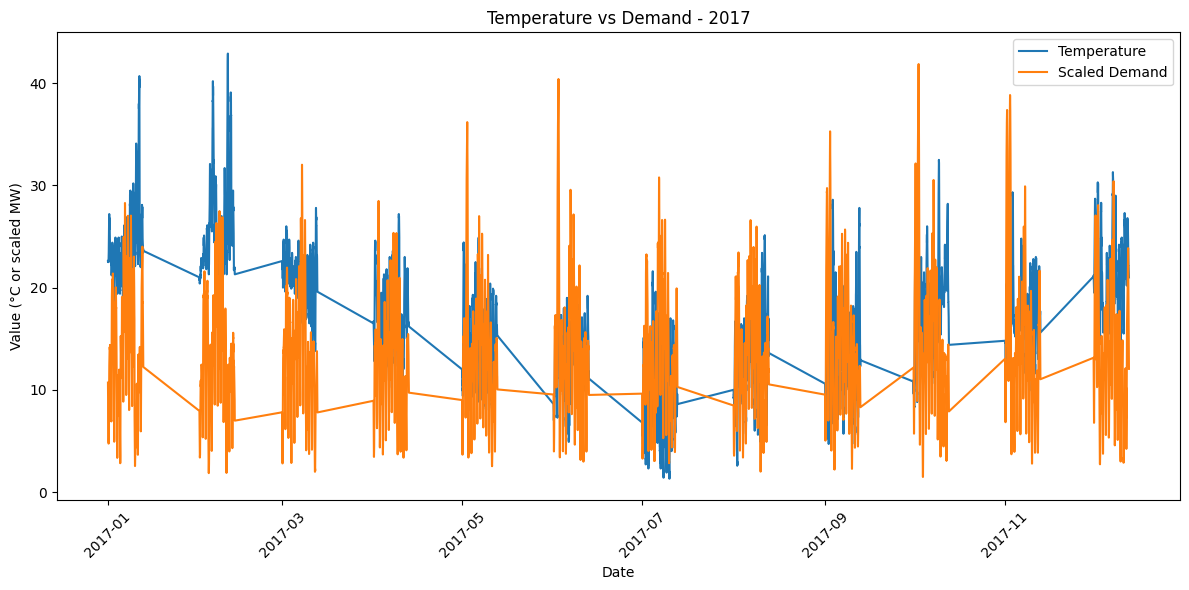

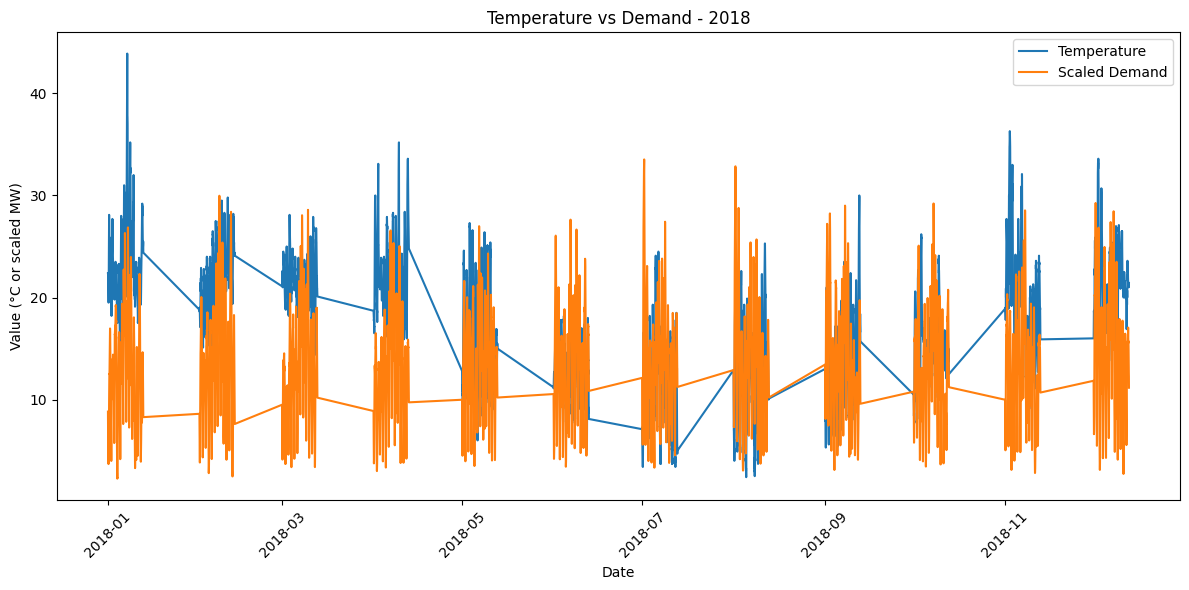

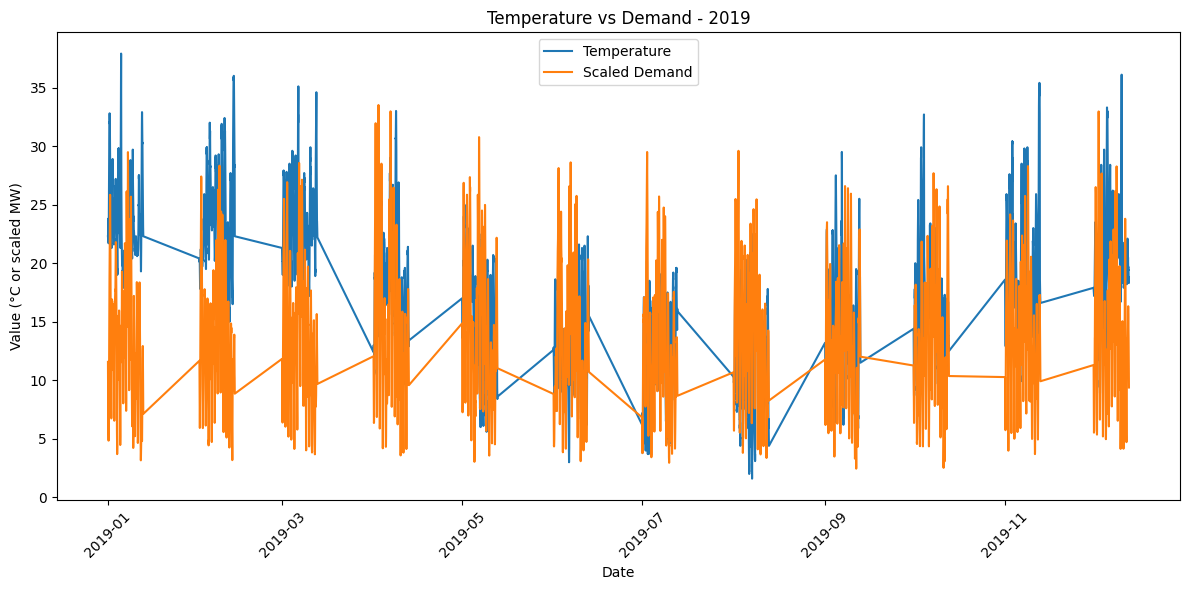

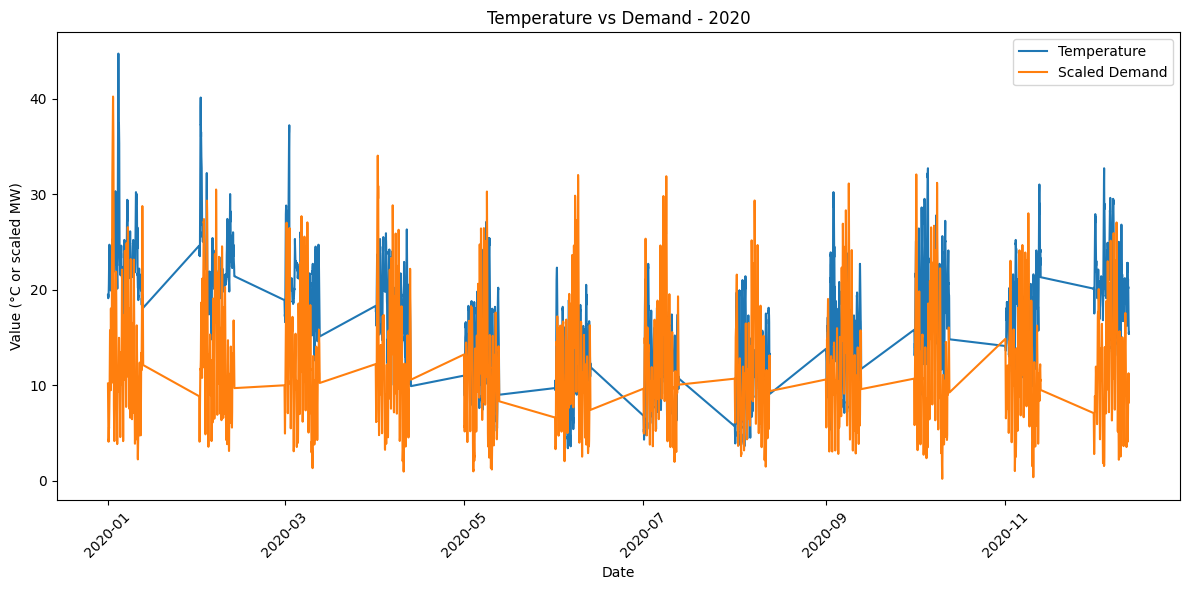

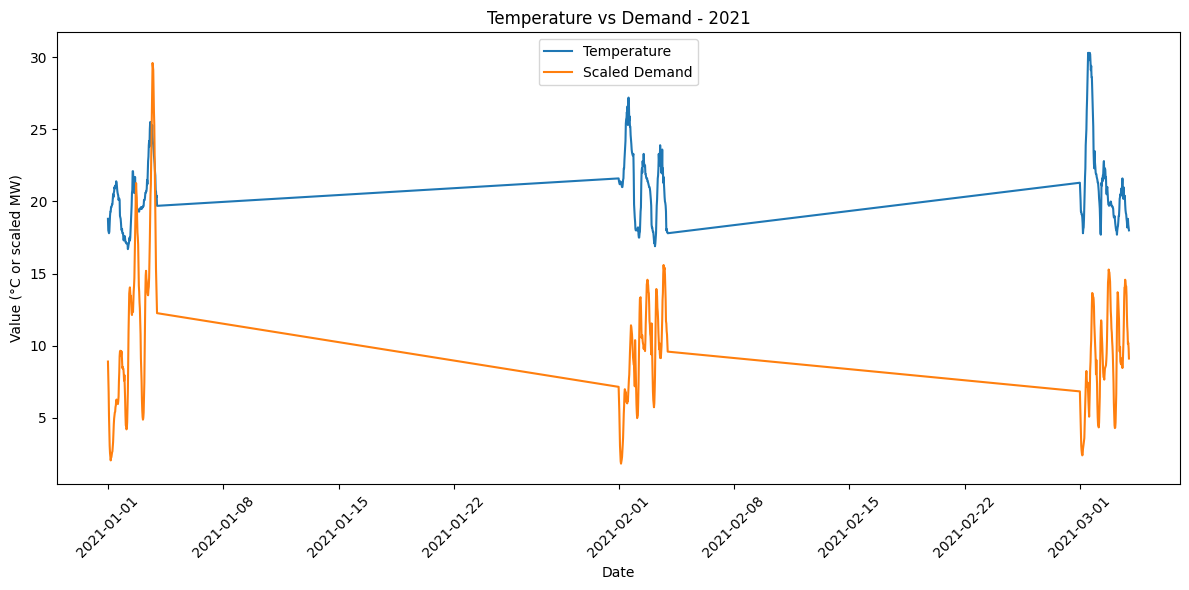

In [ ]:
# Ensure datetime index
ac_df.index = pd.to_datetime(ac_df.index)
ac_df = ac_df.sort_index()

# Extract year list correctly
years = ac_df.index.year.drop_duplicates().tolist()

# Loop through each year and create a plot
for year in sorted(ac_df.index.year.unique()):
    start = f"{year}-01-01"
    end = f"{year}-12-31 23:59:59"

    df_year = ac_df.loc[start:end]

    if df_year.empty:
        print(f"No data for {year}")
        continue

    plt.figure(figsize=(12, 6))
    sns.lineplot(x=df_year.index, y=df_year["TEMPERATURE"], label="Temperature")
    sns.lineplot(x=df_year.index, y=df_year["DEMAND_mm2temp"], label="Scaled Demand")

    plt.title(f"Temperature vs Demand - {year}")
    plt.xlabel("Date")
    plt.ylabel("Value (°C or scaled MW)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

As we can see the Demand is Low when temperature is high, when the temperature drops demand starts to match

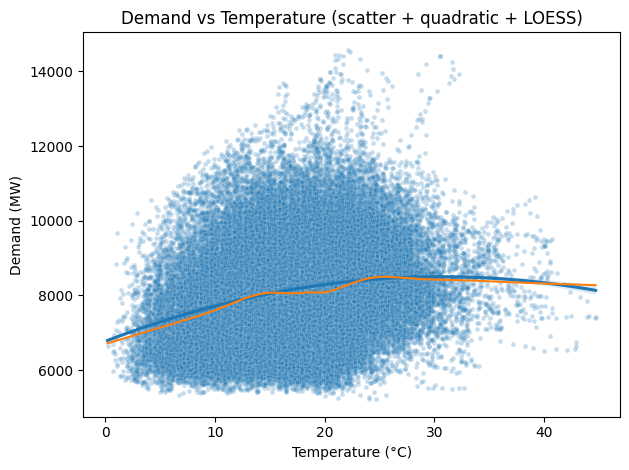

In [ ]:
x = ac_df["TEMPERATURE"]; y = ac_df["TOTALDEMAND"]

plt.figure()
sns.scatterplot(x=x, y=y, alpha=0.25, s=12)
sns.regplot(x=x, y=y, scatter=False, order=2)  # quadratic fit
lo = lowess(y, x, frac=0.25, return_sorted=True)
plt.plot(lo[:,0], lo[:,1])
plt.title("Demand vs Temperature (scatter + quadratic + LOESS)")
plt.xlabel("Temperature (°C)"); plt.ylabel("Demand (MW)"); plt.tight_layout()

Now we are going to compare the Forecasted demand and the actual demand

In [ ]:
df3.head()


,PREDISPATCHSEQNO,REGIONID,PERIODID,FORECASTDEMAND,LASTCHANGED,DATETIME
0,2009123018,NSW1,71.0,7832.04,2009-12-30 12:31:49,2010-01-01 00:00:00
1,2009123019,NSW1,70.0,7832.04,2009-12-30 13:01:43,2010-01-01 00:00:00
2,2009123020,NSW1,69.0,7832.03,2009-12-30 13:31:36,2010-01-01 00:00:00
3,2009123021,NSW1,68.0,7832.03,2009-12-30 14:01:44,2010-01-01 00:00:00
4,2009123022,NSW1,67.0,7830.96,2009-12-30 14:31:35,2010-01-01 00:00:00


In [ ]:
#Check for null values
print(f"Null Values => {df3.isna().sum().sort_values(ascending=False)}")
#Check for datatypes
print(f"Data Types**  {df3.dtypes}")

Null Values => REGIONID            1
PERIODID            1
LASTCHANGED         1
FORECASTDEMAND      1
DATETIME            1
PREDISPATCHSEQNO    0
dtype: int64
Data Types**  PREDISPATCHSEQNO      int64
REGIONID             object
PERIODID            float64
FORECASTDEMAND      float64
LASTCHANGED          object
DATETIME             object
dtype: object


In [ ]:
#Drop null values
df3.dropna(inplace=True)
print(f"Null Values => {df3.isna().sum().sort_values(ascending=False)}")

Null Values => PREDISPATCHSEQNO    0
REGIONID            0
PERIODID            0
FORECASTDEMAND      0
LASTCHANGED         0
DATETIME            0
dtype: int64


In [ ]:
#Setting Datetime as index
df3["DATETIME"]  = pd.to_datetime(df3["DATETIME"],  errors="coerce")
df3 = df3.set_index("DATETIME")

In [ ]:
actual_demand=df2['TOTALDEMAND']
forecasted_demand=df3['FORECASTDEMAND']

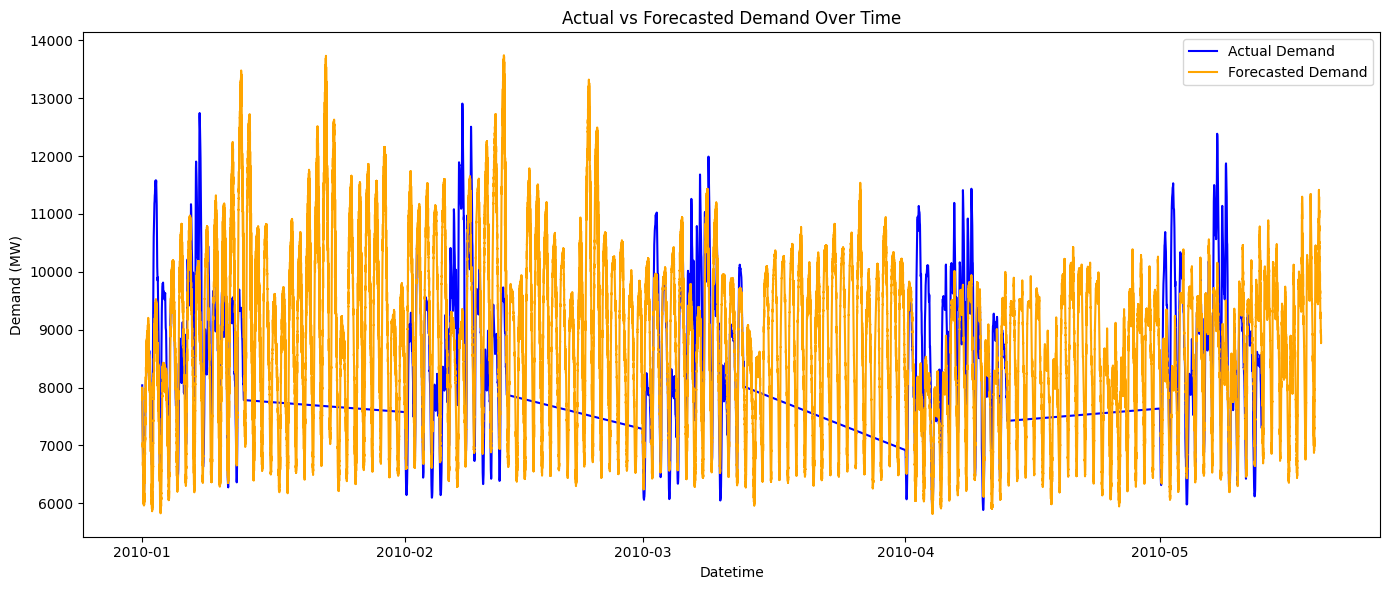

In [ ]:

cutoff_date = "2010-05-20"
df2_filtered = df2[df2.index <= cutoff_date]
df3_filtered = df3[df3.index <= cutoff_date]
df2_filtered = df2_filtered.sort_index()
plt.figure(figsize=(14,6))

plt.plot(df2_filtered.index, df2_filtered['TOTALDEMAND'], label='Actual Demand', color='blue')
plt.plot(df3_filtered.index, df3_filtered['FORECASTDEMAND'], label='Forecasted Demand', color='orange')
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.title("Actual vs Forecasted Demand Over Time")
plt.legend()
plt.tight_layout()
plt.show()